In [29]:
# ── Cell 1: Install & Imports ─────────────────────────────────────────────────
import subprocess, sys

# Install packages compatible with numpy 2.x (no downgrade needed)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm==0.9.12", "grad-cam", "kaggle"], check=True)

import os, json, time, random, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from tqdm.notebook import tqdm
from IPython.display import display, clear_output
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
import timm

from sklearn.metrics import (confusion_matrix, f1_score,
                              classification_report, top_k_accuracy_score)
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ numpy     {np.__version__}")
print(f"✅ torch     {torch.__version__}")
print(f"✅ timm      {timm.__version__}")
print(f"✅ Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU")

✅ numpy     2.4.3
✅ torch     2.10.0+cu128
✅ timm      0.9.12
✅ Device  : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB


In [30]:
# ── Mount Google Drive (checkpoints saved here) ─────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Project directory structure ──────────────────────────────────────────────
DRIVE_ROOT  = Path("/content/drive/MyDrive/ButterflyProject")
CKPT_DIR    = DRIVE_ROOT / "checkpoints"
RESULTS_DIR = DRIVE_ROOT / "results"
PLOTS_DIR   = DRIVE_ROOT / "plots"

for d in [CKPT_DIR, RESULTS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATA_DIR    = Path("/content/butterfly_data")
DATA_DIR.mkdir(exist_ok=True)

print("✅ Google Drive mounted")
print(f"   Checkpoints → {CKPT_DIR}")
print(f"   Results     → {RESULTS_DIR}")
print(f"   Plots       → {PLOTS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted
   Checkpoints → /content/drive/MyDrive/ButterflyProject/checkpoints
   Results     → /content/drive/MyDrive/ButterflyProject/results
   Plots       → /content/drive/MyDrive/ButterflyProject/plots


In [31]:
# ── Kaggle API setup ─────────────────────────────────────────────────────────
# Upload kaggle.json interactively
from google.colab import files

kaggle_cfg = Path("/root/.kaggle/kaggle.json")
if not kaggle_cfg.exists():
    # Check if already saved in Drive
    drive_kaggle = DRIVE_ROOT / "kaggle.json"
    if drive_kaggle.exists():
        os.makedirs("/root/.kaggle", exist_ok=True)
        shutil.copy(drive_kaggle, kaggle_cfg)
        os.chmod(kaggle_cfg, 0o600)
        print("✅ kaggle.json loaded from Drive")
    else:
        print("⬆️  Please upload your kaggle.json file:")
        uploaded = files.upload()
        os.makedirs("/root/.kaggle", exist_ok=True)
        shutil.move(list(uploaded.keys())[0], kaggle_cfg)
        os.chmod(kaggle_cfg, 0o600)
        # Save to Drive for future sessions
        shutil.copy(kaggle_cfg, drive_kaggle)
        print("✅ kaggle.json saved to Drive for future sessions")
else:
    print("✅ kaggle.json already configured")

✅ kaggle.json already configured


In [32]:
# ── Download & prepare dataset ───────────────────────────────────────────────
RAW_DIR = DATA_DIR / "raw"

if not RAW_DIR.exists() or len(list(RAW_DIR.glob("**/*.jpg"))) < 1000:
    print("⬇️  Downloading butterfly dataset from Kaggle...")
    !kaggle datasets download -d gpiosenka/butterfly-images40-species -p {DATA_DIR} --unzip
    # Find extracted folder
    extracted = [d for d in DATA_DIR.iterdir() if d.is_dir()]
    print(f"   Extracted folders: {[d.name for d in extracted]}")
else:
    print("✅ Dataset already downloaded")

# ── Locate train/test/valid folders ──────────────────────────────────────────
possible_roots = list(DATA_DIR.rglob("train"))
if possible_roots:
    DATASET_ROOT = possible_roots[0].parent
    print(f"✅ Dataset root: {DATASET_ROOT}")
    TRAIN_RAW = DATASET_ROOT / "train"
    VALID_RAW = DATASET_ROOT / "valid"
    TEST_RAW  = DATASET_ROOT / "test"
    for split, p in [("Train", TRAIN_RAW), ("Valid", VALID_RAW), ("Test", TEST_RAW)]:
        if p.exists():
            n = len(list(p.rglob("*.jpg"))) + len(list(p.rglob("*.JPG")))
            print(f"   {split}: {len(list(p.iterdir()))} classes, {n} images")
else:
    print("❌ Could not find dataset. Check download above.")

⬇️  Downloading butterfly dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/gpiosenka/butterfly-images40-species
License(s): CC0-1.0
100% 399M/399M [00:02<00:00, 177MB/s]

   Extracted folders: ['split_50', 'train', 'valid', 'test']
✅ Dataset root: /content/butterfly_data
   Train: 100 classes, 12594 images
   Valid: 100 classes, 500 images
   Test: 100 classes, 500 images


In [33]:
# ── Subsample to 50 species (stratified) ────────────────────────────────────
import shutil

NUM_SPECIES = 50
SPLIT_DIR   = DATA_DIR / f"split_{NUM_SPECIES}"
TRAIN_DIR   = SPLIT_DIR / "train"
VALID_DIR   = SPLIT_DIR / "valid"
TEST_DIR    = SPLIT_DIR / "test"

if not SPLIT_DIR.exists():
    print(f"⚙️  Creating {NUM_SPECIES}-species split...")
    random.seed(SEED)

    # Get all species from training set
    all_species = sorted([d.name for d in TRAIN_RAW.iterdir() if d.is_dir()])
    selected    = random.sample(all_species, min(NUM_SPECIES, len(all_species)))
    selected.sort()
    print(f"   Selected {len(selected)} species")

    for split_src, split_dst in [(TRAIN_RAW, TRAIN_DIR),
                                  (VALID_RAW, VALID_DIR),
                                  (TEST_RAW,  TEST_DIR)]:
        for sp in selected:
            src = split_src / sp
            dst = split_dst / sp
            if src.exists():
                shutil.copytree(src, dst)

    # Save selected species list
    with open(SPLIT_DIR / "selected_species.json", "w") as f:
        json.dump(selected, f, indent=2)
    print(f"✅ Split created at {SPLIT_DIR}")
else:
    with open(SPLIT_DIR / "selected_species.json") as f:
        selected = json.load(f)
    print(f"✅ Split already exists — {len(selected)} species")

# Final counts
for name, path in [("Train", TRAIN_DIR), ("Valid", VALID_DIR), ("Test", TEST_DIR)]:
    n_imgs = len(list(path.rglob("*.jpg"))) + len(list(path.rglob("*.JPG")))
    print(f"   {name}: {n_imgs} images")

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"\n✅ NUM_CLASSES = {NUM_CLASSES}")

✅ Split already exists — 50 species
   Train: 6273 images
   Valid: 250 images
   Test: 250 images

✅ NUM_CLASSES = 50


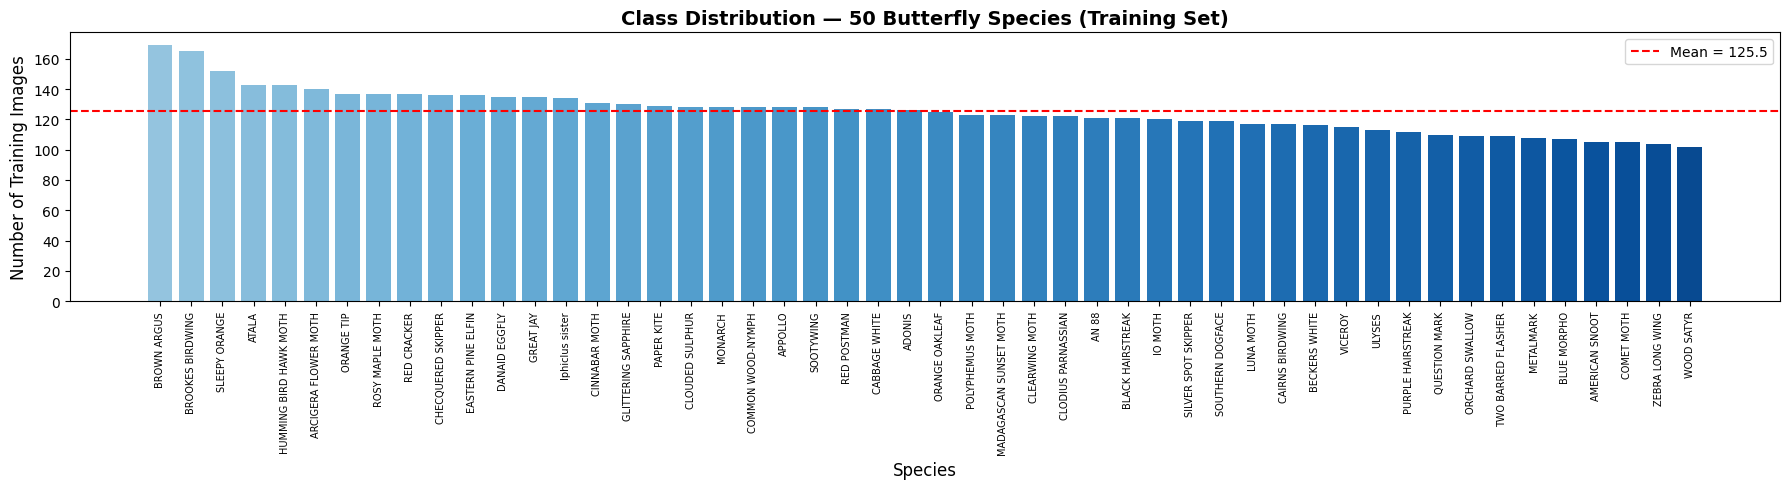

📊 Class imbalance ratio (max/min): 169/102 = 1.66x
   Mean images per class : 125.5
   Std                   : 14.4


In [34]:
# ── 3.1 Class distribution bar chart ────────────────────────────────────────
class_counts = {}
for sp in CLASS_NAMES:
    n = len(list((TRAIN_DIR / sp).glob("*.jpg"))) +         len(list((TRAIN_DIR / sp).glob("*.JPG")))
    class_counts[sp] = n

counts = pd.Series(class_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(18, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(counts)))
ax.bar(range(len(counts)), counts.values, color=colors)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=90, fontsize=7)
ax.set_xlabel("Species", fontsize=12)
ax.set_ylabel("Number of Training Images", fontsize=12)
ax.set_title(f"Class Distribution — {NUM_CLASSES} Butterfly Species (Training Set)", fontsize=14, fontweight='bold')
ax.axhline(counts.mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean = {counts.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Class imbalance ratio (max/min): {counts.max()}/{counts.min()} = {counts.max()/counts.min():.2f}x")
print(f"   Mean images per class : {counts.mean():.1f}")
print(f"   Std                   : {counts.std():.1f}")

In [ ]:
# ── 3.2 Sample image grid (5×5) ─────────────────────────────────────────────
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
sample_classes = random.sample(CLASS_NAMES, 25)

for ax, sp in zip(axes.flat, sample_classes):
    imgs = list((TRAIN_DIR / sp).glob("*.jpg")) + list((TRAIN_DIR / sp).glob("*.JPG"))
    if imgs:
        img = Image.open(random.choice(imgs)).convert("RGB")
        ax.imshow(img)
    ax.set_title(sp.replace("_", " "), fontsize=7, pad=2)
    ax.axis('off')

plt.suptitle("Sample Images — 25 Random Species", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_sample_grid.png", dpi=120, bbox_inches='tight')
plt.show()

Sampling image resolutions (first 500 images)...


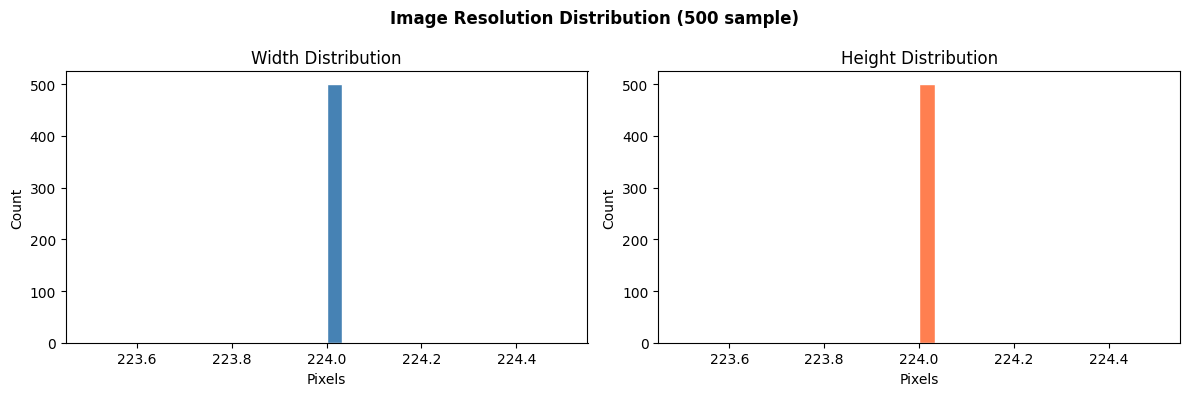

Width  — mean: 224px, range: 224–224px
Height — mean: 224px, range: 224–224px


In [ ]:
# ── 3.3 Image resolution distribution ───────────────────────────────────────
# ── 3.3 Image resolution distribution ────────────────────────────────────────
TRAIN_DIR = Path("/content/butterfly_data/split_50/train")  # safety fallback
print("Sampling image resolutions (first 500 images)...")
widths, heights = [], []
all_imgs = (list(TRAIN_DIR.rglob("*.jpg")) + list(TRAIN_DIR.rglob("*.JPG")))[:500]

for p in all_imgs:
    try:
        w, h = Image.open(p).size
        widths.append(w); heights.append(h)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Width Distribution"); axes[0].set_xlabel("Pixels")
axes[1].hist(heights, bins=30, color='coral', edgecolor='white')
axes[1].set_title("Height Distribution"); axes[1].set_xlabel("Pixels")
for ax in axes: ax.set_ylabel("Count")
plt.suptitle("Image Resolution Distribution (500 sample)", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_resolution.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Width  — mean: {np.mean(widths):.0f}px, range: {min(widths)}–{max(widths)}px")
print(f"Height — mean: {np.mean(heights):.0f}px, range: {min(heights)}–{max(heights)}px")

In [ ]:
# ── 3.4 Pixel statistics (mean & std per channel) ────────────────────────────
print("Computing pixel statistics (sample of 300 images)...")
temp_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
sample_imgs = random.sample(all_imgs, min(300, len(all_imgs)))

channel_means, channel_stds = [], []
for p in sample_imgs:
    try:
        t = temp_tf(Image.open(p).convert("RGB"))
        channel_means.append(t.mean(dim=[1,2]).numpy())
        channel_stds.append(t.std(dim=[1,2]).numpy())
    except:
        pass

means = np.mean(channel_means, axis=0)
stds  = np.mean(channel_stds, axis=0)

print("\n📊 Pixel Statistics (normalised 0–1):")
for i, ch in enumerate(['Red', 'Green', 'Blue']):
    print(f"   {ch}: mean={means[i]:.4f}, std={stds[i]:.4f}")
print("\n(These are close to ImageNet stats — ImageNet normalisation is appropriate ✅)")

Computing pixel statistics (sample of 300 images)...

📊 Pixel Statistics (normalised 0–1):
   Red: mean=0.4843, std=0.2478
   Green: mean=0.4962, std=0.2472
   Blue: mean=0.4333, std=0.2754

(These are close to ImageNet stats — ImageNet normalisation is appropriate ✅)


In [ ]:
# ── Transforms ───────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
valid_dataset = datasets.ImageFolder(VALID_DIR, transform=eval_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

# ── Class weights for imbalanced loss ────────────────────────────────────────
class_sample_counts = np.array([count for _, count in sorted(Counter(train_dataset.targets).items())])
class_weights = 1.0 / class_sample_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalise
CLASS_WEIGHTS = torch.FloatTensor(class_weights).to(DEVICE)

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ DataLoaders ready")
print(f"   Train : {len(train_dataset):,} images | {len(train_loader)} batches")
print(f"   Valid : {len(valid_dataset):,} images | {len(valid_loader)} batches")
print(f"   Test  : {len(test_dataset):,}  images | {len(test_loader)} batches")
print(f"   Classes: {NUM_CLASSES} | Batch size: {BATCH_SIZE}")

✅ DataLoaders ready
   Train : 6,273 images | 197 batches
   Valid : 250 images | 8 batches
   Test  : 250  images | 8 batches
   Classes: 50 | Batch size: 32


In [ ]:
# ── Build all 3 models ────────────────────────────────────────────────────────

def build_efficientnet_b0(num_classes):
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
    return model

def build_mobilenetv3_small(num_classes):
    model = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=num_classes)
    return model

def build_deit_tiny(num_classes):
    model = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=num_classes)
    return model

MODEL_REGISTRY = {
    "EfficientNet-B0":    build_efficientnet_b0,
    "MobileNetV3-Small":  build_mobilenetv3_small,
    "DeiT-Tiny":          build_deit_tiny,
}

# ── Freeze / unfreeze helpers ─────────────────────────────────────────────────

def freeze_backbone(model, model_name):
    """Freeze all layers except the classification head."""
    if "DeiT" in model_name:
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False
    else:
        # timm models: classifier is last layer
        for name, param in model.named_parameters():
            if 'classifier' not in name and 'head' not in name:
                param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"   Frozen backbone — trainable: {trainable:,} / {total:,} params")

def unfreeze_last_blocks(model, model_name):
    """Unfreeze last 1-2 blocks + head for fine-tuning."""
    # First unfreeze everything
    for param in model.parameters():
        param.requires_grad = True

    if "EfficientNet" in model_name:
        # Freeze everything except last block (blocks[6]) and head
        for name, param in model.named_parameters():
            if not any(x in name for x in ['blocks.6', 'conv_head', 'classifier', 'bn2']):
                param.requires_grad = False

    elif "MobileNet" in model_name:
        # Freeze everything except last 2 blocks and classifier
        for name, param in model.named_parameters():
            if not any(x in name for x in ['blocks.5', 'blocks.6', 'classifier', 'conv_head']):
                param.requires_grad = False

    elif "DeiT" in model_name:
        # Freeze everything except last 2 transformer blocks and head
        for name, param in model.named_parameters():
            if not any(x in name for x in ['blocks.10', 'blocks.11', 'norm', 'head']):
                param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"   Partial unfreeze  — trainable: {trainable:,} / {total:,} params")

# ── Quick model summary ───────────────────────────────────────────────────────
print("📋 Model Overview:")
for name, builder in MODEL_REGISTRY.items():
    m = builder(NUM_CLASSES)
    total = sum(p.numel() for p in m.parameters()) / 1e6
    size  = sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6
    print(f"   {name:<22} | Params: {total:.2f}M | Size: {size:.1f} MB")
    del m

In [ ]:
# ── Core training & validation functions ─────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast():
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = total_loss / total
    acc      = correct / total
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def save_checkpoint(state, path):
    torch.save(state, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    if optimizer and 'optimizer_state' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state'])
    if scheduler and 'scheduler_state' in ckpt:
        scheduler.load_state_dict(ckpt['scheduler_state'])
    return ckpt.get('epoch', 0), ckpt.get('best_val_acc', 0.0)

print("✅ Training engine ready")

In [ ]:
# ── Master training function ──────────────────────────────────────────────────

def train_model(model_name, phase, total_epochs_this_phase, lr):
    """
    Train a model for one phase.
    phase = 1 (frozen backbone) or 2 (partial unfreeze)
    Automatically resumes from last checkpoint.
    """
    print(f"\n{'='*60}")
    print(f"  {model_name} | Phase {phase} | LR={lr} | Epochs={total_epochs_this_phase}")
    print(f"{'='*60}")

    model = MODEL_REGISTRY[model_name](NUM_CLASSES).to(DEVICE)

    if phase == 1:
        freeze_backbone(model, model_name)
        optimizer_cls = optim.AdamW if "DeiT" in model_name else optim.Adam
    else:
        unfreeze_last_blocks(model, model_name)
        optimizer_cls = optim.AdamW if "DeiT" in model_name else optim.Adam

    optimizer  = optimizer_cls(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    criterion  = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    scheduler  = CosineAnnealingLR(optimizer, T_max=total_epochs_this_phase)
    scaler     = GradScaler()

    # ── Checkpoint paths ──────────────────────────────────────────────────────
    ckpt_latest = CKPT_DIR / f"{model_name.replace(' ','_')}_phase{phase}_latest.pt"
    ckpt_best   = CKPT_DIR / f"{model_name.replace(' ','_')}_phase{phase}_best.pt"

    # If phase 2, load best model from phase 1
    if phase == 2:
        p1_best = CKPT_DIR / f"{model_name.replace(' ','_')}_phase1_best.pt"
        if p1_best.exists():
            print(f"   Loading Phase 1 best weights...")
            ckpt = torch.load(p1_best, map_location=DEVICE)
            model.load_state_dict(ckpt['model_state'])
            unfreeze_last_blocks(model, model_name)  # re-apply after loading
            optimizer = optimizer_cls(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
            scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs_this_phase)
            scaler    = GradScaler()
        else:
            print("⚠️  Phase 1 best checkpoint not found. Training from scratch.")

    # ── Resume from latest if exists ─────────────────────────────────────────
    start_epoch   = 0
    best_val_acc  = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

    if ckpt_latest.exists():
        print(f"   Resuming from {ckpt_latest.name}...")
        ckpt = torch.load(ckpt_latest, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch  = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_val_acc']
        history      = ckpt.get('history', history)
        print(f"   Resumed at epoch {start_epoch}, best val acc so far: {best_val_acc:.4f}")

    if start_epoch >= total_epochs_this_phase:
        print(f"   ✅ Already completed all {total_epochs_this_phase} epochs. Skipping.")
        return history, best_val_acc

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, total_epochs_this_phase):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        vl_loss, vl_acc, vl_f1, _, _, _ = validate(model, valid_loader, criterion)
        scheduler.step()
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)

        improved = "⭐" if vl_acc > best_val_acc else "  "
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            save_checkpoint({'model_state': model.state_dict(),
                             'epoch': epoch, 'best_val_acc': best_val_acc,
                             'history': history}, ckpt_best)

        print(f"  {improved} Ep {epoch+1:02d}/{total_epochs_this_phase} | "
              f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
              f"Acc {tr_acc:.4f}/{vl_acc:.4f} | "
              f"F1 {vl_f1:.4f} | {elapsed:.0f}s")

        # Save latest every epoch (protects against disconnects)
        save_checkpoint({'model_state': model.state_dict(),
                         'optimizer_state': optimizer.state_dict(),
                         'scheduler_state': scheduler.state_dict(),
                         'epoch': epoch, 'best_val_acc': best_val_acc,
                         'history': history}, ckpt_latest)

    print(f"\n✅ Phase {phase} complete. Best val acc: {best_val_acc:.4f}")
    return history, best_val_acc

print("✅ Master training function ready")

In [ ]:
# ── Global results store ─────────────────────────────────────────────────────
# This dict accumulates across all training cells
ALL_HISTORIES  = {}
ALL_PHASE_ACCS = {}  # {model_name: {phase1_acc, phase2_acc}}
PHASE_EPOCHS   = 7
LR_PHASE1      = 1e-3
LR_PHASE2      = 1e-4
print("✅ Config set: PHASE_EPOCHS=7, LR_P1=1e-3, LR_P2=1e-4")

In [ ]:
# ── 7.1 EfficientNet-B0 ───────────────────────────────────────────────────────
hist_p1, acc_p1 = train_model("EfficientNet-B0", phase=1, total_epochs_this_phase=PHASE_EPOCHS, lr=LR_PHASE1)
hist_p2, acc_p2 = train_model("EfficientNet-B0", phase=2, total_epochs_this_phase=PHASE_EPOCHS, lr=LR_PHASE2)
ALL_HISTORIES["EfficientNet-B0"] = {"phase1": hist_p1, "phase2": hist_p2}
ALL_PHASE_ACCS["EfficientNet-B0"] = {"phase1": acc_p1, "phase2": acc_p2}
print(f"\n🦋 EfficientNet-B0 done | P1: {acc_p1:.4f} → P2: {acc_p2:.4f} (+{acc_p2-acc_p1:.4f})")

In [ ]:
# ── 7.2 MobileNetV3-Small ─────────────────────────────────────────────────────
hist_p1, acc_p1 = train_model("MobileNetV3-Small", phase=1, total_epochs_this_phase=PHASE_EPOCHS, lr=LR_PHASE1)
hist_p2, acc_p2 = train_model("MobileNetV3-Small", phase=2, total_epochs_this_phase=PHASE_EPOCHS, lr=LR_PHASE2)
ALL_HISTORIES["MobileNetV3-Small"] = {"phase1": hist_p1, "phase2": hist_p2}
ALL_PHASE_ACCS["MobileNetV3-Small"] = {"phase1": acc_p1, "phase2": acc_p2}
print(f"\n🦋 MobileNetV3-Small done | P1: {acc_p1:.4f} → P2: {acc_p2:.4f} (+{acc_p2-acc_p1:.4f})")

In [ ]:
# ── 7.3 DeiT-Tiny ─────────────────────────────────────────────────────────────
hist_p1, acc_p1 = train_model("DeiT-Tiny", phase=1, total_epochs_this_phase=PHASE_EPOCHS, lr=LR_PHASE1)
hist_p2, acc_p2 = train_model("DeiT-Tiny", phase=2, total_epochs_this_phase=PHASE_EPOCHS, lr=LR_PHASE2)
ALL_HISTORIES["DeiT-Tiny"] = {"phase1": hist_p1, "phase2": hist_p2}
ALL_PHASE_ACCS["DeiT-Tiny"] = {"phase1": acc_p1, "phase2": acc_p2}
print(f"\n🦋 DeiT-Tiny done | P1: {acc_p1:.4f} → P2: {acc_p2:.4f} (+{acc_p2-acc_p1:.4f})")

In [ ]:
# ── Load best Phase-2 models and evaluate on test set ────────────────────────

def evaluate_on_test(model_name):
    """Load best checkpoint and run full test-set evaluation."""
    model    = MODEL_REGISTRY[model_name](NUM_CLASSES).to(DEVICE)
    ckpt_path = CKPT_DIR / f"{model_name.replace(' ','_')}_phase2_best.pt"

    if not ckpt_path.exists():
        # fallback to phase1
        ckpt_path = CKPT_DIR / f"{model_name.replace(' ','_')}_phase1_best.pt"
        print(f"⚠️  Phase2 ckpt not found, using Phase1 for {model_name}")

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    _, acc1, f1, y_true, y_pred, y_prob = validate(model, test_loader, criterion)

    # Top-3 accuracy
    acc3 = top_k_accuracy_score(y_true, y_prob, k=3, labels=list(range(NUM_CLASSES)))

    # Model size & param count
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    model_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6

    # Inference time (avg over 100 samples)
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        for _ in range(10): model(dummy)  # warm up
    t0 = time.time()
    with torch.no_grad():
        for _ in range(100): model(dummy)
    inf_time_ms = (time.time() - t0) / 100 * 1000

    result = {
        "top1_acc": acc1, "top3_acc": acc3, "f1": f1,
        "params_m": total_params, "size_mb": model_size_mb,
        "inf_time_ms": inf_time_ms,
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob
    }
    return result, model


print("Evaluating all models on test set...")
TEST_RESULTS = {}
LOADED_MODELS = {}

for name in MODEL_REGISTRY:
    print(f"\n── {name} ──")
    res, mdl = evaluate_on_test(name)
    TEST_RESULTS[name] = res
    LOADED_MODELS[name] = mdl
    print(f"   Top-1: {res['top1_acc']:.4f} | Top-3: {res['top3_acc']:.4f} | F1: {res['f1']:.4f}")
    print(f"   Params: {res['params_m']:.2f}M | Size: {res['size_mb']:.1f}MB | Inf: {res['inf_time_ms']:.2f}ms")

In [ ]:
# ── Main comparison table ─────────────────────────────────────────────────────
print("\n" + "="*85)
print(f"{'Model':<22} {'Top-1':>7} {'Top-3':>7} {'F1':>7} {'Params(M)':>10} {'Size(MB)':>9} {'Inf(ms)':>8}")
print("="*85)
for name, r in TEST_RESULTS.items():
    print(f"{name:<22} {r['top1_acc']:>7.4f} {r['top3_acc']:>7.4f} {r['f1']:>7.4f} "
          f"{r['params_m']:>10.2f} {r['size_mb']:>9.1f} {r['inf_time_ms']:>8.2f}")
print("="*85)

# ── Phase-wise accuracy table ─────────────────────────────────────────────────
if ALL_PHASE_ACCS:
    print("\nPhase-wise Accuracy:")
    print(f"{'Model':<22} {'Phase 1':>10} {'Phase 2':>10} {'Gain':>8}")
    print("-"*55)
    for name, accs in ALL_PHASE_ACCS.items():
        gain = accs['phase2'] - accs['phase1']
        print(f"{name:<22} {accs['phase1']:>10.4f} {accs['phase2']:>10.4f} {gain:>+8.4f}")

# ── Save results to Drive ─────────────────────────────────────────────────────
summary = {name: {k: float(v) if isinstance(v, (float, np.floating)) else v
                  for k, v in r.items() if k not in ('y_true','y_pred','y_prob')}
           for name, r in TEST_RESULTS.items()}
with open(RESULTS_DIR / "test_results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\n✅ Results saved to Drive")

In [ ]:
# ── 9.1 Loss & accuracy curves (per model) ───────────────────────────────────

for model_name, histories in ALL_HISTORIES.items():
    # Combine phase 1 + phase 2 histories
    combined = {k: histories['phase1'][k] + histories['phase2'][k]
                for k in ['train_loss','val_loss','train_acc','val_acc']}
    epochs = range(1, len(combined['train_loss']) + 1)
    ep_boundary = len(histories['phase1']['train_loss'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training Curves", fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(epochs, combined['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs, combined['val_loss'],   label='Val Loss',   color='coral')
    axes[0].axvline(ep_boundary + 0.5, color='gray', linestyle='--', linewidth=1, label='Phase 2 start')
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, combined['train_acc'], label='Train Acc', color='steelblue')
    axes[1].plot(epochs, combined['val_acc'],   label='Val Acc',   color='coral')
    axes[1].axvline(ep_boundary + 0.5, color='gray', linestyle='--', linewidth=1, label='Phase 2 start')
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    for ax in axes: ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"curves_{model_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── 9.2 Confusion matrices ────────────────────────────────────────────────────

for model_name, res in TEST_RESULTS.items():
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm, ax=ax, cmap='Blues', linewidths=0.3,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot=False, cbar=True)
    ax.set_title(f"{model_name} — Confusion Matrix (Test Set)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.tick_params(axis='x', rotation=90, labelsize=5)
    ax.tick_params(axis='y', rotation=0,  labelsize=5)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"cm_{model_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── 9.3 Accuracy vs Parameters scatter ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_map = {"EfficientNet-B0": "steelblue", "MobileNetV3-Small": "coral", "DeiT-Tiny": "green"}

for name, res in TEST_RESULTS.items():
    c = colors_map[name]
    axes[0].scatter(res['params_m'], res['top1_acc']*100, s=200, color=c, label=name, zorder=5)
    axes[0].annotate(name, (res['params_m'], res['top1_acc']*100),
                     textcoords="offset points", xytext=(8, 4), fontsize=9)

    axes[1].scatter(res['inf_time_ms'], res['top1_acc']*100, s=200, color=c, label=name, zorder=5)
    axes[1].annotate(name, (res['inf_time_ms'], res['top1_acc']*100),
                     textcoords="offset points", xytext=(8, 4), fontsize=9)

axes[0].set_xlabel("Parameters (M)", fontsize=12)
axes[0].set_ylabel("Top-1 Accuracy (%)", fontsize=12)
axes[0].set_title("Accuracy vs Model Size", fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].set_xlabel("Inference Time (ms)", fontsize=12)
axes[1].set_ylabel("Top-1 Accuracy (%)", fontsize=12)
axes[1].set_title("Accuracy vs Inference Speed", fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "scatter_tradeoffs.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 9.4 Phase-wise accuracy bar chart ────────────────────────────────────────
if ALL_PHASE_ACCS:
    names   = list(ALL_PHASE_ACCS.keys())
    p1_accs = [ALL_PHASE_ACCS[n]['phase1']*100 for n in names]
    p2_accs = [ALL_PHASE_ACCS[n]['phase2']*100 for n in names]
    x = np.arange(len(names)); w = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x - w/2, p1_accs, w, label='Phase 1 (Frozen)',   color='steelblue', alpha=0.85)
    b2 = ax.bar(x + w/2, p2_accs, w, label='Phase 2 (Fine-tuned)', color='coral', alpha=0.85)

    ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
    ax.set_ylabel("Val Accuracy (%)"); ax.set_ylim(0, 100)
    ax.set_title("Phase 1 vs Phase 2 Accuracy per Model", fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "phase_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── Ablation 1: Effect of Augmentation ───────────────────────────────────────
# Train EfficientNet-B0 Phase 1 WITHOUT augmentation and compare

print("Ablation 1: Augmentation Effect")
print("Training EfficientNet-B0 Phase 1 WITHOUT augmentation...")

no_aug_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

no_aug_dataset = datasets.ImageFolder(TRAIN_DIR, transform=no_aug_transform)
no_aug_loader  = DataLoader(no_aug_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

# ── Train no-aug version ─────────────────────────────────────────────────────
model_noaug = MODEL_REGISTRY["EfficientNet-B0"](NUM_CLASSES).to(DEVICE)
freeze_backbone(model_noaug, "EfficientNet-B0")
optimizer_noaug = optim.Adam(filter(lambda p: p.requires_grad, model_noaug.parameters()), lr=LR_PHASE1)
criterion_noaug = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
scaler_noaug    = GradScaler()
scheduler_noaug = CosineAnnealingLR(optimizer_noaug, T_max=PHASE_EPOCHS)

noaug_val_accs = []
for ep in range(PHASE_EPOCHS):
    t0 = time.time()
    tr_l, tr_a = train_one_epoch(model_noaug, no_aug_loader, optimizer_noaug, criterion_noaug, scaler_noaug)
    vl_l, vl_a, vl_f1, _, _, _ = validate(model_noaug, valid_loader, criterion_noaug)
    scheduler_noaug.step()
    noaug_val_accs.append(vl_a)
    print(f"  Ep {ep+1}/{PHASE_EPOCHS} | Acc {tr_a:.4f}/{vl_a:.4f} | {time.time()-t0:.0f}s")

# ── Compare with aug version ──────────────────────────────────────────────────
aug_val_accs = ALL_HISTORIES.get("EfficientNet-B0", {}).get("phase1", {}).get("val_acc", [])

print(f"\n📊 Ablation 1 Results:")
print(f"   With Augmentation    — Best Val Acc: {max(aug_val_accs):.4f}" if aug_val_accs else "   (Run section 7 first)")
print(f"   Without Augmentation — Best Val Acc: {max(noaug_val_accs):.4f}")
if aug_val_accs:
    delta = max(aug_val_accs) - max(noaug_val_accs)
    print(f"   Augmentation gain   : +{delta:.4f} ({delta*100:.2f}%)")

# ── Plot ─────────────────────────────────────────────────────────────────────
epochs_range = range(1, PHASE_EPOCHS + 1)
fig, ax = plt.subplots(figsize=(8, 5))
if aug_val_accs:
    ax.plot(epochs_range, aug_val_accs[:PHASE_EPOCHS], label='With Augmentation', color='steelblue', marker='o')
ax.plot(epochs_range, noaug_val_accs, label='Without Augmentation', color='coral', marker='s', linestyle='--')
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy")
ax.set_title("Ablation 1 — Effect of Data Augmentation\n(EfficientNet-B0, Phase 1)", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ablation1_augmentation.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Ablation 2: Phase 1 vs Phase 2 deep-dive ────────────────────────────────
# Already computed — visualise with per-class breakdown

if ALL_PHASE_ACCS:
    print("Ablation 2: Phase-wise Accuracy Deep-Dive\n")

    # Load phase1 best models and get test accuracy
    ablation2_results = {}
    for name in MODEL_REGISTRY:
        p1_ckpt = CKPT_DIR / f"{name.replace(' ','_')}_phase1_best.pt"
        p2_ckpt = CKPT_DIR / f"{name.replace(' ','_')}_phase2_best.pt"
        model_tmp = MODEL_REGISTRY[name](NUM_CLASSES).to(DEVICE)
        criterion  = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

        p1_test_acc = None
        if p1_ckpt.exists():
            model_tmp.load_state_dict(torch.load(p1_ckpt, map_location=DEVICE)['model_state'])
            _, p1_test_acc, _, _, _, _ = validate(model_tmp, test_loader, criterion)

        p2_test_acc = None
        if p2_ckpt.exists():
            model_tmp.load_state_dict(torch.load(p2_ckpt, map_location=DEVICE)['model_state'])
            _, p2_test_acc, _, _, _, _ = validate(model_tmp, test_loader, criterion)

        ablation2_results[name] = {"p1": p1_test_acc, "p2": p2_test_acc}
        print(f"  {name:<22} | Phase1 Test Acc: {p1_test_acc:.4f} | Phase2 Test Acc: {p2_test_acc:.4f} | "
              f"Gain: +{(p2_test_acc - p1_test_acc):.4f}")
        del model_tmp

    # ── Plot ──────────────────────────────────────────────────────────────────
    names   = list(ablation2_results.keys())
    p1_vals = [ablation2_results[n]['p1']*100 for n in names]
    p2_vals = [ablation2_results[n]['p2']*100 for n in names]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(names)); w = 0.35
    b1 = ax.bar(x - w/2, p1_vals, w, label='Phase 1 (Feature Extraction)', color='steelblue', alpha=0.85)
    b2 = ax.bar(x + w/2, p2_vals, w, label='Phase 2 (Fine-Tuned)',           color='seagreen',  alpha=0.85)
    ax.bar_label(b1, fmt='%.2f%%', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.2f%%', padding=3, fontsize=9)

    # Draw gain arrows
    for i, (p1, p2) in enumerate(zip(p1_vals, p2_vals)):
        ax.annotate(f"+{p2-p1:.1f}%", xy=(i + w/2, p2 + 1), ha='center', fontsize=9, color='darkgreen', fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 105)
    ax.set_ylabel("Test Accuracy (%)"); ax.set_title("Ablation 2 — Fine-tuning Benefit per Architecture", fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "ablation2_finetuning.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Run Section 7 first to populate ALL_PHASE_ACCS")

In [ ]:
# ──────────────────── Grad-CAM helper────────────────────────────────────────────
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def get_gradcam_target_layer(model, model_name):
    if "EfficientNet" in model_name:
        return model.conv_head
    elif "MobileNet" in model_name:
        for block in reversed(list(model.blocks)):
            for sublayer in reversed(list(block.modules())):
                if isinstance(sublayer, torch.nn.Conv2d):
                    return sublayer
        return None
    elif "DeiT" in model_name:
        return model.blocks[-1].norm1
    return None


def reshape_transform_deit(tensor, height=14, width=14):
    """
    DeiT outputs shape [B, 197, C] — 196 patch tokens + 1 cls token.
    Drop cls token, reshape to spatial [B, C, H, W] for Grad-CAM.
    """
    result = tensor[:, 1:, :]          # drop cls token → [B, 196, C]
    result = result.reshape(result.size(0), height, width, result.size(2))
    result = result.transpose(2, 3).transpose(1, 2)  # → [B, C, H, W]
    return result


def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def show_gradcam_grid(model, model_name, test_dataset, num_correct=4, num_wrong=4):
    target_layer = get_gradcam_target_layer(model, model_name)
    if target_layer is None:
        print(f"⚠️  No target layer found for {model_name}")
        return

    # Use reshape_transform only for DeiT
    is_vit = "DeiT" in model_name
    cam_cls = GradCAMPlusPlus if is_vit else GradCAM
    cam = cam_cls(
        model=model,
        target_layers=[target_layer],
        reshape_transform=reshape_transform_deit if is_vit else None
    )

    model.eval()
    correct_samples, wrong_samples = [], []

    for img_tensor, label in test_dataset:
        if len(correct_samples) >= num_correct and len(wrong_samples) >= num_wrong:
            break
        inp  = img_tensor.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = model(inp).argmax(1).item()
        if pred == label and len(correct_samples) < num_correct:
            correct_samples.append((img_tensor, label, pred))
        elif pred != label and len(wrong_samples) < num_wrong:
            wrong_samples.append((img_tensor, label, pred))

    for title, samples in [("✅ Correct", correct_samples), ("❌ Wrong", wrong_samples)]:
        if not samples:
            continue
        n = len(samples)
        fig, axes = plt.subplots(2, n, figsize=(n * 4, 8))
        if n == 1:
            axes = axes.reshape(2, 1)
        fig.suptitle(f"{model_name} — Grad-CAM ({title})", fontsize=13, fontweight='bold')

        for col, (img_t, true_lbl, pred_lbl) in enumerate(samples):
            # Original image
            orig_np = denormalize(img_t).permute(1, 2, 0).numpy()
            axes[0, col].imshow(orig_np)
            axes[0, col].set_title(f"True: {CLASS_NAMES[true_lbl][:15]}", fontsize=8)
            axes[0, col].axis('off')

            # Grad-CAM overlay
            inp = img_t.unsqueeze(0).to(DEVICE)
            targets = [ClassifierOutputTarget(pred_lbl)]
            grayscale_cam = cam(input_tensor=inp, targets=targets)[0]

            # Ensure grayscale_cam is 2D
            if grayscale_cam.ndim == 3:
                grayscale_cam = grayscale_cam.mean(axis=0)

            cam_img = show_cam_on_image(
                orig_np.astype(np.float32),
                grayscale_cam,
                use_rgb=True
            )
            axes[1, col].imshow(cam_img)
            axes[1, col].set_title(f"Pred: {CLASS_NAMES[pred_lbl][:15]}", fontsize=8)
            axes[1, col].axis('off')

        axes[0, 0].set_ylabel("Original", fontsize=10)
        axes[1, 0].set_ylabel("Grad-CAM", fontsize=10)
        plt.tight_layout()
        fname = f"gradcam_{model_name.replace(' ', '_')}_{title.split()[1].lower()}.png"
        plt.savefig(PLOTS_DIR / fname, dpi=120, bbox_inches='tight')
        plt.show()


# ── Run for all 3 models ──────────────────────────────────────────────────────
for name, model in LOADED_MODELS.items():
    print(f"\nGenerating Grad-CAM for {name}...")
    show_gradcam_grid(model, name, test_dataset)

In [ ]:
# ── Section 12: Interactive Demo — fully self-contained ──────────────────────
from pathlib import Path
import torch, json, time, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import transforms
from PIL import Image
import timm
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DRIVE_ROOT  = Path("/content/drive/MyDrive/ButterflyProject")
CKPT_DIR    = DRIVE_ROOT / "checkpoints"
RESULTS_DIR = DRIVE_ROOT / "results"
PLOTS_DIR   = DRIVE_ROOT / "plots"
TEST_DIR    = Path("/content/butterfly_data/split_50/test")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Load class names ──────────────────────────────────────────────────────────
CLASS_NAMES = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

# ── Load best model from results ──────────────────────────────────────────────
with open(RESULTS_DIR / "test_results_summary.json") as f:
    TEST_RESULTS = json.load(f)

best_model_name = max(TEST_RESULTS, key=lambda n: TEST_RESULTS[n]['top1_acc'])
best_stats      = TEST_RESULTS[best_model_name]

_registry = {
    "EfficientNet-B0":   lambda n: timm.create_model('efficientnet_b0',       pretrained=False, num_classes=n),
    "MobileNetV3-Small": lambda n: timm.create_model('mobilenetv3_small_100', pretrained=False, num_classes=n),
    "DeiT-Tiny":         lambda n: timm.create_model('deit_tiny_patch16_224', pretrained=False, num_classes=n),
}

best_model = _registry[best_model_name](NUM_CLASSES).to(DEVICE)
ckpt = torch.load(CKPT_DIR / f"{best_model_name.replace(' ','_')}_phase2_best.pt",
                  map_location=DEVICE)
best_model.load_state_dict(ckpt['model_state'])
best_model.eval()
print(f"✅ Loaded: {best_model_name} | Top-1: {best_stats['top1_acc']*100:.2f}%")

# ── Grad-CAM setup ────────────────────────────────────────────────────────────
def get_target_layer(model, name):
    if "EfficientNet" in name:
        return model.conv_head
    elif "MobileNet" in name:
        for block in reversed(list(model.blocks)):
            for sub in reversed(list(block.modules())):
                if isinstance(sub, torch.nn.Conv2d):
                    return sub
    elif "DeiT" in name:
        return model.blocks[-1].norm1

def reshape_deit(tensor, h=14, w=14):
    r = tensor[:, 1:, :]
    r = r.reshape(r.size(0), h, w, r.size(2))
    return r.transpose(2, 3).transpose(1, 2)

def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t * std + mean).clamp(0,1)

is_vit       = "DeiT" in best_model_name
target_layer = get_target_layer(best_model, best_model_name)
cam          = GradCAMPlusPlus(
    model=best_model,
    target_layers=[target_layer],
    reshape_transform=reshape_deit if is_vit else None
)

# ── Single predict function ───────────────────────────────────────────────────
def predict(img_path):
    img    = Image.open(img_path).convert("RGB")
    img_t  = eval_transform(img).unsqueeze(0).to(DEVICE)
    true_label = Path(img_path).parent.name.replace("_", " ").title()

    # Inference
    t0 = time.time()
    with torch.no_grad():
        probs = torch.softmax(best_model(img_t), dim=1)[0]
    inf_ms = (time.time() - t0) * 1000

    top5_vals, top5_idx = torch.topk(probs, 5)

    # Grad-CAM
    orig_np       = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
    grayscale_cam = cam(input_tensor=img_t,
                        targets=[ClassifierOutputTarget(top5_idx[0].item())])[0]
    if grayscale_cam.ndim == 3:
        grayscale_cam = grayscale_cam.mean(axis=0)
    cam_img = show_cam_on_image(orig_np, grayscale_cam, use_rgb=True)

    pred_label  = CLASS_NAMES[top5_idx[0].item()].replace("_", " ").title()
    is_correct  = pred_label.lower() == true_label.lower()
    result_icon = "✅" if is_correct else "❌"

    return {
        "img":        img.resize((224, 224)),
        "cam_img":    cam_img,
        "top5_vals":  [v.item() for v in top5_vals],
        "top5_names": [CLASS_NAMES[i.item()].replace("_"," ").title() for i in top5_idx],
        "true_label": true_label,
        "pred_label": pred_label,
        "is_correct": is_correct,
        "result_icon": result_icon,
        "inf_ms":     inf_ms,
    }

# ── Beautiful multi-sample dashboard ─────────────────────────────────────────
def run_demo(n_samples=6, seed=42):
    random.seed(seed)
    all_imgs = list(TEST_DIR.rglob("*.jpg")) + list(TEST_DIR.rglob("*.JPG"))

    # Pick half correct, half wrong predictions
    correct_imgs, wrong_imgs = [], []
    random.shuffle(all_imgs)
    for p in all_imgs:
        if len(correct_imgs) >= n_samples//2 and len(wrong_imgs) >= n_samples//2:
            break
        r = predict(p)
        if r['is_correct'] and len(correct_imgs) < n_samples//2:
            correct_imgs.append(r)
        elif not r['is_correct'] and len(wrong_imgs) < n_samples//2:
            wrong_imgs.append(r)

    samples = correct_imgs + wrong_imgs

    # ── Dashboard layout ──────────────────────────────────────────────────────
    n   = len(samples)
    fig = plt.figure(figsize=(20, n * 4.5))
    fig.patch.set_facecolor('#0f0f0f')

    # Title banner
    fig.text(0.5, 0.98,  "🦋  Butterfly Species Recognition — Prediction Dashboard",
             ha='center', va='top', fontsize=18, fontweight='bold', color='white')
    fig.text(0.5, 0.965,
             f"Model: {best_model_name}   |   Top-1 Acc: {best_stats['top1_acc']*100:.2f}%   |"
             f"   Params: {best_stats['params_m']:.1f}M   |   Size: {best_stats['size_mb']:.1f}MB",
             ha='center', va='top', fontsize=11, color='#aaaaaa')

    gs = gridspec.GridSpec(n, 3, figure=fig,
                           left=0.04, right=0.97,
                           top=0.94, bottom=0.02,
                           hspace=0.45, wspace=0.25)

    for row, r in enumerate(samples):
        bg_color = '#1a2e1a' if r['is_correct'] else '#2e1a1a'
        ax_color = '#2a3d2a' if r['is_correct'] else '#3d2a2a'

        # ── Col 0: Original image ─────────────────────────────────────────────
        ax0 = fig.add_subplot(gs[row, 0])
        ax0.imshow(r['img'])
        ax0.set_facecolor(bg_color)
        ax0.set_title(f"True:  {r['true_label']}",
                      color='white', fontsize=9, pad=4)
        ax0.set_xlabel(f"{r['result_icon']}  Pred: {r['pred_label']}  ({r['inf_ms']:.1f}ms)",
                       color='#00ff88' if r['is_correct'] else '#ff6666',
                       fontsize=9, labelpad=4)
        ax0.set_xticks([]); ax0.set_yticks([])
        for spine in ax0.spines.values():
            spine.set_edgecolor('#00ff88' if r['is_correct'] else '#ff4444')
            spine.set_linewidth(2)

        # ── Col 1: Grad-CAM ───────────────────────────────────────────────────
        ax1 = fig.add_subplot(gs[row, 1])
        ax1.imshow(r['cam_img'])
        ax1.set_facecolor(bg_color)
        ax1.set_title("Grad-CAM Attention", color='white', fontsize=9, pad=4)
        ax1.set_xlabel("Red = most attended region", color='#aaaaaa', fontsize=8, labelpad=4)
        ax1.set_xticks([]); ax1.set_yticks([])
        for spine in ax1.spines.values():
            spine.set_edgecolor('#888888'); spine.set_linewidth(1)

        # ── Col 2: Confidence bar chart ───────────────────────────────────────
        ax2 = fig.add_subplot(gs[row, 2])
        ax2.set_facecolor(ax_color)
        names  = [n[:22] for n in r['top5_names']]
        values = [v * 100 for v in r['top5_vals']]
        bar_colors = ['#00ff88' if i == 0 and r['is_correct']
                      else '#ff4444' if i == 0 and not r['is_correct']
                      else '#4a90d9' for i in range(5)]
        bars = ax2.barh(names[::-1], values[::-1],
                        color=bar_colors[::-1], edgecolor='none', height=0.6)
        for bar, val in zip(bars, values[::-1]):
            ax2.text(min(val + 1, 95), bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', color='white', fontsize=8.5, fontweight='bold')
        ax2.set_xlim(0, 105)
        ax2.set_xlabel("Confidence (%)", color='#aaaaaa', fontsize=8)
        ax2.set_title("Top-5 Predictions", color='white', fontsize=9, pad=4)
        ax2.tick_params(colors='#cccccc', labelsize=8)
        ax2.xaxis.label.set_color('#aaaaaa')
        for spine in ax2.spines.values():
            spine.set_edgecolor('#555555')
        ax2.set_facecolor(ax_color)
        fig.patch.set_facecolor('#0f0f0f')

    # Save
    out_path = PLOTS_DIR / "demo_dashboard.png"
    plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print(f"✅ Dashboard saved → {out_path}")
    print(f"   Correct: {sum(1 for r in samples if r['is_correct'])}/{n_samples} shown")

# ── Run ───────────────────────────────────────────────────────────────────────
run_demo(n_samples=6)

In [ ]:
# ── Section 13: Final Summary ─────────────────────────────────────────────────
from pathlib import Path
import json

DRIVE_ROOT  = Path("/content/drive/MyDrive/ButterflyProject")
RESULTS_DIR = DRIVE_ROOT / "results"

# Load results from Drive
with open(RESULTS_DIR / "test_results_summary.json") as f:
    TEST_RESULTS = json.load(f)

print("="*60)
print("         BUTTERFLY PROJECT — FINAL SUMMARY")
print("="*60)

print("\n🏆 Model Comparison (Test Set):")
ranked = sorted(TEST_RESULTS.items(), key=lambda x: x[1]['top1_acc'], reverse=True)
for rank, (name, r) in enumerate(ranked, 1):
    print(f"  #{rank} {name:<22} Top-1: {r['top1_acc']*100:.2f}% | F1: {r['f1']:.4f} | "
          f"Inf: {r['inf_time_ms']:.1f}ms | {r['params_m']:.1f}M params")

print("\n🧪 Ablation Highlights:")
print("  Ablation 1 — Augmentation effect: see plots/ablation1_augmentation.png")
print("  Ablation 2 — Fine-tuning benefit: see plots/ablation2_finetuning.png")

print("\n💾 Files saved to Google Drive:")
for f in sorted(DRIVE_ROOT.rglob("*")):
    if f.is_file():
        size = f.stat().st_size / 1e6
        print(f"  {str(f.relative_to(DRIVE_ROOT)):<55} {size:.1f} MB")

print("\n✅ Project complete!")

         BUTTERFLY PROJECT — FINAL SUMMARY

🏆 Model Comparison (Test Set):
  #1 DeiT-Tiny              Top-1: 98.00% | F1: 0.9798 | Inf: 5.0ms | 5.5M params
  #2 EfficientNet-B0        Top-1: 96.40% | F1: 0.9632 | Inf: 8.6ms | 4.1M params
  #3 MobileNetV3-Small      Top-1: 96.00% | F1: 0.9597 | Inf: 5.4ms | 1.6M params

🧪 Ablation Highlights:
  Ablation 1 — Augmentation effect: see plots/ablation1_augmentation.png
  Ablation 2 — Fine-tuning benefit: see plots/ablation2_finetuning.png

💾 Files saved to Google Drive:
  CNN_vs_ViT_Butterfly_Species_Recognition.ipynb          0.2 MB
  checkpoints/DeiT-Tiny_phase1_best.pt                    22.2 MB
  checkpoints/DeiT-Tiny_phase1_latest.pt                  22.3 MB
  checkpoints/DeiT-Tiny_phase2_best.pt                    22.2 MB
  checkpoints/DeiT-Tiny_phase2_latest.pt                  29.5 MB
  checkpoints/EfficientNet-B0_phase1_best.pt              16.6 MB
  checkpoints/EfficientNet-B0_phase1_latest.pt            20.4 MB
  checkpoints/Effi